# 05. 리밸런싱 시점별 계층적 군집화
각 리밸런싱 시점(그 날짜의 종목 단면)마다 독립적으로 표준화 + 군집화한다. 안정성 지표(beta, volatility)는 2배 가중치를 적용해 "안정성 1순위" 전략을 반영하고, 평균 안정성 점수가 가장 낮은 군집을 "안정 그룹"으로 라벨링한다.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('/Users/choedasom/lab_middle_project')
assert (PROJECT_ROOT / 'src' / 'cluster.py').is_file(), f'경로 확인 필요: {PROJECT_ROOT}'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]

import pandas as pd
from src.cluster import cluster_all_snapshots

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

PROJECT_ROOT: /Users/choedasom/lab_middle_project


In [2]:
rebalance_60df = pd.read_parquet(PROCESSED_DIR / 'rebalance_60df.parquet')
print(f'rebalance_60df: {rebalance_60df.shape}, {rebalance_60df["Ticker"].nunique()}종목, {rebalance_60df["Date"].nunique()}개 시점')
rebalance_60df.head()

rebalance_60df: (21530, 6), 679종목, 44개 시점


,Date,Ticker,beta_60d,volatility_60d,return_60d,rsi_60d
0,2016-01-04,A,NaN,NaN,NaN,NaN
1,2016-03-31,A,1.271214,0.285565,-0.020644,49.314015
2,2016-06-24,A,1.239632,0.203317,0.110356,60.183147
3,2016-09-20,A,1.559464,0.226525,0.038768,53.663637
4,2016-12-14,A,1.342155,0.228246,0.011914,51.464840


In [3]:
# 계층적 군집화(Ward linkage) + 안정성 지표 2배 가중치, 시점별 독립 실행
clustered_60df = cluster_all_snapshots(rebalance_60df, window=60, n_clusters=3, stability_weight=2.0)

clustered_60df.to_parquet(PROCESSED_DIR / 'clustered_60df.parquet', index=False)
print(f'clustered_60df 저장 완료: {clustered_60df.shape}')
clustered_60df.head()

clustered_60df 저장 완료: (21530, 8)


,Date,Ticker,beta_60d,volatility_60d,return_60d,rsi_60d,cluster,is_stable_cluster
0,2016-01-04,A,NaN,NaN,NaN,NaN,-1,False
1,2016-01-04,AABA,NaN,NaN,NaN,NaN,-1,False
2,2016-01-04,AAL,NaN,NaN,NaN,NaN,-1,False
3,2016-01-04,AAP,NaN,NaN,NaN,NaN,-1,False
4,2016-01-04,AAPL,NaN,NaN,NaN,NaN,-1,False


In [4]:
# 첫 시점(데이터 워밍업 구간이라 전부 cluster=-1)은 제외하고 확인
valid = clustered_60df[clustered_60df['cluster'] != -1]

summary = valid.groupby('Date').agg(
    전체종목수=('Ticker', 'size'),
    안정그룹종목수=('is_stable_cluster', 'sum'),
)
summary['안정그룹비율'] = (summary['안정그룹종목수'] / summary['전체종목수']).round(3)
print(f'제외된 워밍업 구간 행 수: {(clustered_60df["cluster"]==-1).shape[0] - valid.shape[0]}')
summary.describe()

제외된 워밍업 구간 행 수: 482


,전체종목수,안정그룹종목수,안정그룹비율
count,43.000000,43.000000,43.000000
mean,489.488372,227.488372,0.464395
std,9.184283,79.692376,0.160949
min,464.000000,100.000000,0.213000
25%,483.500000,164.500000,0.338500
50%,493.000000,220.000000,0.467000
75%,496.500000,293.000000,0.601000
max,501.000000,397.000000,0.807000


In [5]:
# 특정 한 시점을 예시로, 안정 그룹 vs 나머지 그룹의 지표 평균 비교
sample_date = summary.index[len(summary)//2]
sample = valid[valid['Date'] == sample_date]

print(f'예시 시점: {sample_date}')
print(sample.groupby('is_stable_cluster')[['beta_60d','volatility_60d','return_60d','rsi_60d']].mean())
print()
print('안정 그룹 종목 예시:')
sample[sample['is_stable_cluster']][['Ticker','beta_60d','volatility_60d','return_60d','rsi_60d']].head(10)

예시 시점: 2021-04-01 00:00:00
                   beta_60d  volatility_60d  return_60d    rsi_60d
is_stable_cluster                                                 
False              1.245416        0.422243    0.179272  57.258717
True               0.602179        0.257453    0.090577  55.837204

안정 그룹 종목 예시:


,Ticker,beta_60d,volatility_60d,return_60d,rsi_60d
10602,ABBV,0.790094,0.250931,0.030885,52.679428
10604,ABT,0.528363,0.242550,0.081108,56.162658
10605,ACN,1.127599,0.230350,0.082859,56.422845
10608,ADM,0.998347,0.248895,0.141876,59.534401
10609,ADP,0.687654,0.222732,0.129873,60.037078
10611,AEE,0.129854,0.214283,0.077550,56.066268
10612,AEP,0.174564,0.198925,0.060161,55.166854
10614,AFL,0.627399,0.230137,0.197046,63.329205
10616,AIZ,0.210958,0.278311,0.082627,55.347624
10617,AJG,0.705929,0.211010,0.064217,55.486159


비유: 오디션 심사
군집화(클러스터링) = 어떤 팀에 배정할지 정하는 오디션 심사

4개 항목(beta, volatility, return, rsi)으로 평가하는데, "안정성(beta, volatility)을 2배 더 중요하게 보겠다"고 미리 공지함
그 기준으로 참가자들을 3개 팀으로 나눔 → 여기까지가 "가중치 적용"
라벨링 = 나눠진 팀 중 "진짜 안정적인 팀"이 어디인지 판단

팀을 다 나눈 뒤에, "그럼 어느 팀이 제일 안정적이야?"라고 물으면
아까 2배 뻥튀기한 점수로 답하면 안 됨 (뻥튀기된 숫자는 실제 안정성 크기가 아니라 "팀 나누기용으로 부풀린 임시 점수"일 뿐)
그래서 **원래 점수(가중치 곱하기 전)**로 다시 계산해서 "이 팀 평균 beta/volatility가 진짜로 얼마나 낮은지" 판단함

**가중치(2배)**는 "군집화 알고리즘한테 안정성을 더 중요하게 보라"고 지시하는 도구일 뿐이에요.
근데 "이 그룹이 안정적이다"라는 정의 자체는 원래 표준화 점수(z-score, "평균보다 표준편차 몇 개만큼 낮은가")로 판단해야 의미가 있어요. 2배 부풀린 숫자로 "beta가 1.34만큼 낮다"고 보고하면 실제 표준편차 단위가 아니라서 해석이 이상해져요.
정리하면: 가중치는 "팀을 어떻게 나눌지"에만 관여하고, 나뉜 팀을 "무엇으로 부를지(라벨링)"는 원래 순수한 기준으로 판단한다.

## 시각화 — 안정 그룹 vs 나머지 그룹
위 예시 시점(`sample_date`)을 산점도로 보고, 43개 리밸런싱 시점 전체에서 안정 그룹 비율이 어떻게 움직였는지도 확인한다.

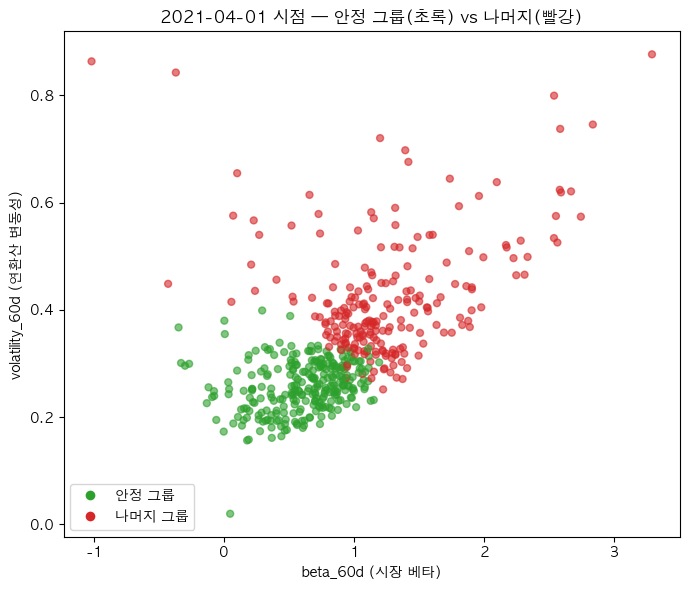

In [6]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

colors = sample['is_stable_cluster'].map({True: '#2ca02c', False: '#d62728'})

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample['beta_60d'], sample['volatility_60d'], c=colors, alpha=0.6, s=25)
ax.set_xlabel('beta_60d (시장 베타)')
ax.set_ylabel('volatility_60d (연환산 변동성)')
ax.set_title(f'{sample_date.date()} 시점 — 안정 그룹(초록) vs 나머지(빨강)')

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markersize=8, label='안정 그룹'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=8, label='나머지 그룹'),
]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

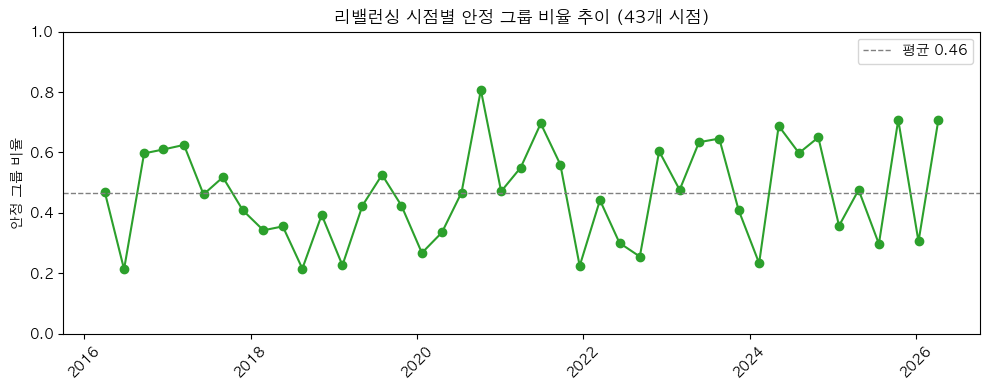

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(summary.index, summary['안정그룹비율'], marker='o', color='#2ca02c')
ax.axhline(
    summary['안정그룹비율'].mean(), color='gray', linestyle='--', linewidth=1,
    label=f"평균 {summary['안정그룹비율'].mean():.2f}",
)
ax.set_ylabel('안정 그룹 비율')
ax.set_title('리밸런싱 시점별 안정 그룹 비율 추이 (43개 시점)')
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 군집 수(`n_clusters=3`) 검증 — 실루엣 점수 & 엘보우
지금까지 3개로 나눈 건 "저위험/중립/고위험" 3단계라는 도메인 감각으로 정한 기본값이었고, 통계적으로 검증한 적은 없었다. 43개 리밸런싱 시점 전체에 대해 k=2~7로 각각 군집화해서, 실루엣 점수(군집이 얼마나 잘 분리됐는지)와 군집 내 분산(WCSS, 엘보우 방법용)을 시점별로 계산하고 평균낸다.

In [8]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

feature_cols = ['beta_60d', 'volatility_60d', 'return_60d', 'rsi_60d']
stability_cols = ['beta_60d', 'volatility_60d']
k_range = range(2, 8)

results = []
for date, group in rebalance_60df.groupby('Date'):
    features = group[feature_cols].dropna()
    if len(features) < max(k_range):
        continue  # 워밍업 구간 등 종목 수가 너무 적은 시점은 제외

    # cluster_snapshot()과 동일한 전처리: 시점별 z-score 표준화 + 안정성 2배 가중치
    z = (features - features.mean()) / features.std(ddof=0)
    z = z.fillna(0.0)
    weights = pd.Series(1.0, index=feature_cols)
    weights[stability_cols] = 2.0
    weighted = (z * weights).to_numpy()

    for k in k_range:
        labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(weighted)
        sil = silhouette_score(weighted, labels)
        # WCSS: 각 군집 내부에서 중심까지 거리 제곱합 (작을수록 군집이 조밀함 = 엘보우 방법의 y축)
        wcss = sum(
            ((weighted[labels == c] - weighted[labels == c].mean(axis=0)) ** 2).sum()
            for c in np.unique(labels)
        )
        results.append({'Date': date, 'k': k, 'silhouette': sil, 'wcss': wcss})

results_df = pd.DataFrame(results)
summary_by_k = results_df.groupby('k')[['silhouette', 'wcss']].mean()
summary_by_k

,silhouette,wcss
k,,
2,0.377228,3112.073746
3,0.297370,2423.089373
4,0.257065,2043.631926
5,0.241575,1766.124968
6,0.236367,1558.835087
7,0.236154,1397.090789


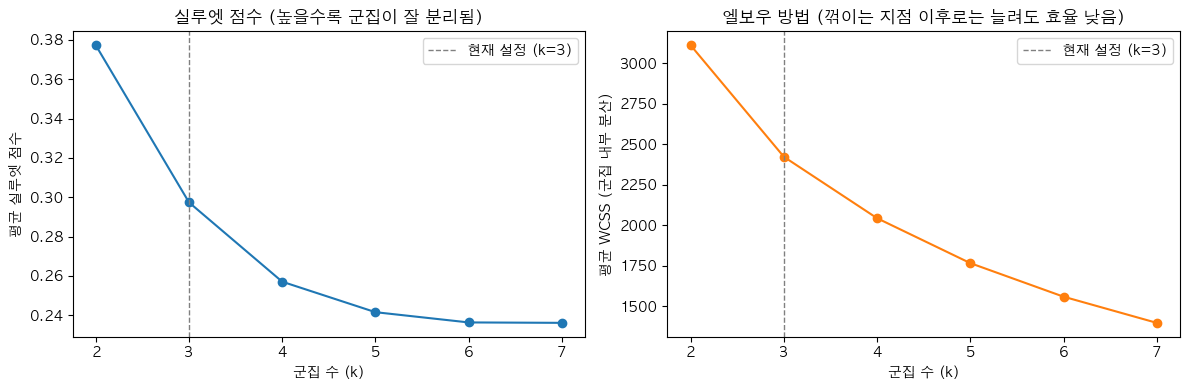

실루엣 점수 최고: k=2 (0.377)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(summary_by_k.index, summary_by_k['silhouette'], marker='o', color='#1f77b4')
axes[0].axvline(3, color='gray', linestyle='--', linewidth=1, label='현재 설정 (k=3)')
axes[0].set_xlabel('군집 수 (k)')
axes[0].set_ylabel('평균 실루엣 점수')
axes[0].set_title('실루엣 점수 (높을수록 군집이 잘 분리됨)')
axes[0].legend()

axes[1].plot(summary_by_k.index, summary_by_k['wcss'], marker='o', color='#ff7f0e')
axes[1].axvline(3, color='gray', linestyle='--', linewidth=1, label='현재 설정 (k=3)')
axes[1].set_xlabel('군집 수 (k)')
axes[1].set_ylabel('평균 WCSS (군집 내부 분산)')
axes[1].set_title('엘보우 방법 (꺾이는 지점 이후로는 늘려도 효율 낮음)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"실루엣 점수 최고: k={summary_by_k['silhouette'].idxmax()} ({summary_by_k['silhouette'].max():.3f})")

### 해석
실루엣 점수는 **k=2에서 가장 높고(0.37), k가 늘어날수록 계속 낮아진다.** k=3(0.31)은 k=2보다 명확히 낮다. WCSS(엘보우)도 뚜렷하게 꺾이는 지점 없이 완만하게 계속 줄어드는 형태라, 엘보우 방법만으로는 3이 특별히 좋다는 근거가 약하다.

즉 통계적으로는 **k=2가 가장 잘 분리된 군집 구조**다 — 공교롭게도 이는 지금 쓰고 있는 "안정 그룹 vs 나머지"라는 이분법과 방향이 같다. 다만 지금 코드는 k=3으로 나눈 뒤 2개 군집을 사후에 합쳐서 "나머지"를 만드는 방식이고, k=2는 처음부터 두 그룹으로 나누는 방식이라 결과가 완전히 같지는 않다.

**결론**: `n_clusters=3`을 유지할 통계적 근거는 약하다. k=2로 바꾸면 더 깔끔하게 분리된 이분법이 되고, k=3을 유지하려면 "왜 3단계 티어링이 전략적으로 필요한가"를 별도로 정당화해야 한다.

## 6단계 — 재군집화 (`n_clusters=2`로 변경)
위 검증 결과에 따라 `n_clusters`를 3에서 2로 바꾼다. 통계적으로 가장 잘 분리되는 구조이면서(실루엣 점수 최고), 애초에 이 전략의 목적이 "안정 그룹이냐 아니냐"라는 이진 판단이라 k=2가 목적과도 자연스럽게 맞는다. `src/cluster.py`의 `DEFAULT_N_CLUSTERS`도 2로 바꿔서, 앞으로는 별도 지정 없이 `cluster_all_snapshots()`를 호출해도 k=2가 기본값이 되도록 했다.

In [10]:
# cluster.py를 수정했으니 캐시를 지우고 다시 import
for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]
from src.cluster import cluster_all_snapshots

clustered_60df = cluster_all_snapshots(rebalance_60df, window=60, n_clusters=2, stability_weight=2.0)
clustered_60df.to_parquet(PROCESSED_DIR / 'clustered_60df.parquet', index=False)
print(f'clustered_60df 재저장 완료 (k=2): {clustered_60df.shape}')

valid = clustered_60df[clustered_60df['cluster'] != -1]
summary = valid.groupby('Date').agg(
    전체종목수=('Ticker', 'size'),
    안정그룹종목수=('is_stable_cluster', 'sum'),
)
summary['안정그룹비율'] = (summary['안정그룹종목수'] / summary['전체종목수']).round(3)
summary.describe()

clustered_60df 재저장 완료 (k=2): (21530, 8)


,전체종목수,안정그룹종목수,안정그룹비율
count,43.000000,43.000000,43.000000
mean,489.488372,307.697674,0.627860
std,9.184283,86.848674,0.174556
min,464.000000,104.000000,0.215000
25%,483.500000,236.000000,0.476000
50%,493.000000,315.000000,0.634000
75%,496.500000,383.000000,0.779500
max,501.000000,466.000000,0.965000


예시 시점: 2021-04-01 00:00:00
                   beta_60d  volatility_60d  return_60d    rsi_60d
is_stable_cluster                                                 
False              1.245416        0.422243    0.179272  57.258717
True               0.602179        0.257453    0.090577  55.837204


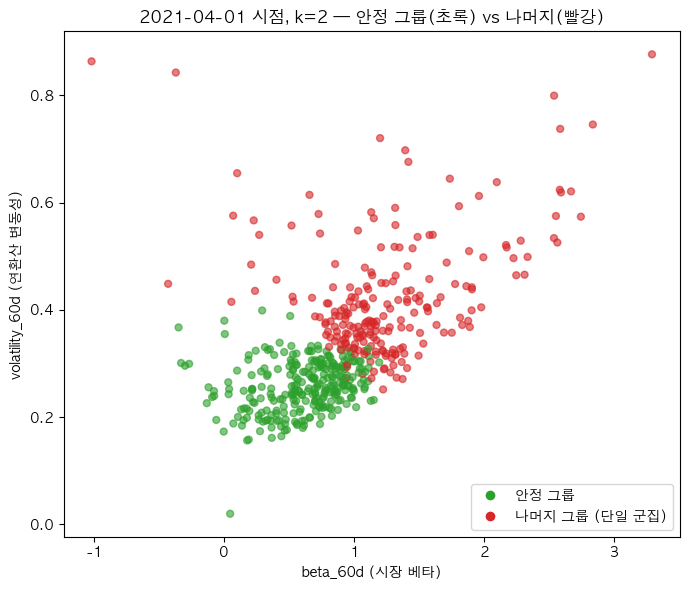

In [11]:
sample_date = summary.index[len(summary) // 2]
sample = valid[valid['Date'] == sample_date]

print(f'예시 시점: {sample_date}')
print(sample.groupby('is_stable_cluster')[['beta_60d', 'volatility_60d', 'return_60d', 'rsi_60d']].mean())

colors = sample['is_stable_cluster'].map({True: '#2ca02c', False: '#d62728'})

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample['beta_60d'], sample['volatility_60d'], c=colors, alpha=0.6, s=25)
ax.set_xlabel('beta_60d (시장 베타)')
ax.set_ylabel('volatility_60d (연환산 변동성)')
ax.set_title(f'{sample_date.date()} 시점, k=2 — 안정 그룹(초록) vs 나머지(빨강)')

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markersize=8, label='안정 그룹'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=8, label='나머지 그룹 (단일 군집)'),
]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

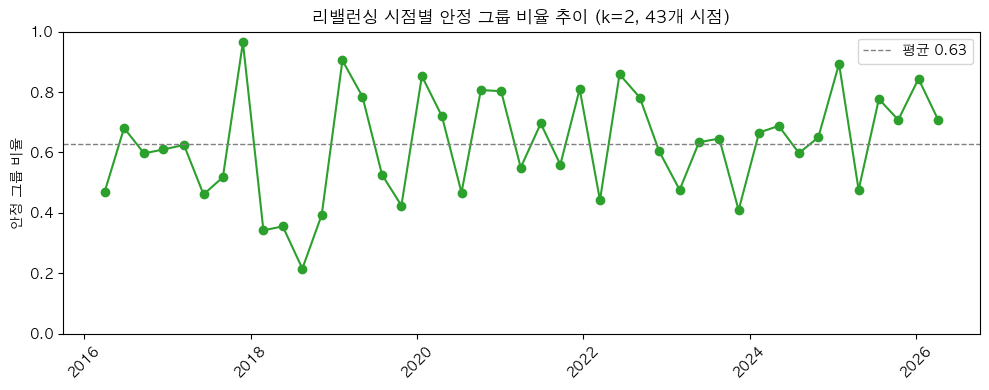

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(summary.index, summary['안정그룹비율'], marker='o', color='#2ca02c')
ax.axhline(
    summary['안정그룹비율'].mean(), color='gray', linestyle='--', linewidth=1,
    label=f"평균 {summary['안정그룹비율'].mean():.2f}",
)
ax.set_ylabel('안정 그룹 비율')
ax.set_title('리밸런싱 시점별 안정 그룹 비율 추이 (k=2, 43개 시점)')
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 다음 단계
- [ ] `is_stable_cluster`로 뽑은 종목들이 다음 60일 동안 실제로 어떤 수익률을 냈는지 계산 (성과 검증)
- [ ] 43개 시점 전체에 대해 이 성과를 누적/집계해서 전략 자체의 유효성 판단
- [ ] 120일 리밸런싱(`rebalance_120df`)에도 동일하게 적용해서 60일 결과와 비교